In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\venka\OneDrive\Documents\influencer_marketing_roi_dataset.csv")

In [4]:
df.head()

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CAMP100000,TikTok,Fitness,Giveaway,2022-01-01 00:00:00,79900,1892,2834,14,2022-01-15 00:00:00
1,CAMP100001,YouTube,Food,Product Launch,2022-01-02 00:00:00,47985,437228,165,13,2022-01-15 00:00:00
2,CAMP100002,TikTok,Travel,Brand Awareness,2022-01-03 00:00:00,13875,982513,2539,5,2022-01-08 00:00:00
3,CAMP100003,YouTube,Food,Brand Awareness,2022-01-04 00:00:00,41200,213400,100,20,2022-01-24 00:00:00
4,CAMP100004,Instagram,Food,Giveaway,2022-01-05 00:00:00,96998,42501,550,28,2022-02-02 00:00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   campaign_id             150000 non-null  object
 1   platform                150000 non-null  object
 2   influencer_category     150000 non-null  object
 3   campaign_type           150000 non-null  object
 4   start_date              150000 non-null  object
 5   engagements             150000 non-null  int64 
 6   estimated_reach         150000 non-null  int64 
 7   product_sales           150000 non-null  int64 
 8   campaign_duration_days  150000 non-null  int64 
 9   end_date                150000 non-null  object
dtypes: int64(4), object(6)
memory usage: 11.4+ MB


In [6]:
df.shape

(150000, 10)

In [7]:
df.describe()

,engagements,estimated_reach,product_sales,campaign_duration_days
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,50065.296107,500239.634920,2497.730433,14.976127
std,28847.302798,288003.388219,1443.222587,8.358356
min,100.000000,1002.000000,0.000000,1.000000
25%,25060.500000,251439.500000,1248.000000,8.000000
50%,50100.500000,500073.500000,2501.000000,15.000000
75%,75045.250000,750016.750000,3746.000000,22.000000
max,99999.000000,999992.000000,4999.000000,29.000000


In [8]:
df.isnull().sum()

campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64

In [9]:
df.fillna(0,inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["Campaign_Cost"] = 500 + (df["estimated_reach"] * 0.01)

In [13]:
df["Revenue"] = df["product_sales"] * 3000

In [14]:
df["ROI"] = (
(df["Revenue"]-df["Campaign_Cost"])
/
df["Campaign_Cost"]
)*100

In [15]:
df["Engagement_Rate"] = (
df["engagements"]
/
df["estimated_reach"]
)*100

In [16]:
df["Cost_Per_Engagement"] = (
df["Campaign_Cost"]
/
df["engagements"]
)

In [17]:
df.head()

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date,Campaign_Cost,Revenue,ROI,Engagement_Rate,Cost_Per_Engagement
0,CAMP100000,TikTok,Fitness,Giveaway,2022-01-01 00:00:00,79900,1892,2834,14,2022-01-15 00:00:00,518.92,8502000,1.638303e+06,4223.044397,0.006495
1,CAMP100001,YouTube,Food,Product Launch,2022-01-02 00:00:00,47985,437228,165,13,2022-01-15 00:00:00,4872.28,495000,1.005951e+04,10.974823,0.101538
2,CAMP100002,TikTok,Travel,Brand Awareness,2022-01-03 00:00:00,13875,982513,2539,5,2022-01-08 00:00:00,10325.13,7617000,7.367147e+04,1.412195,0.744154
3,CAMP100003,YouTube,Food,Brand Awareness,2022-01-04 00:00:00,41200,213400,100,20,2022-01-24 00:00:00,2634.00,300000,1.128952e+04,19.306467,0.063932
4,CAMP100004,Instagram,Food,Giveaway,2022-01-05 00:00:00,96998,42501,550,28,2022-02-02 00:00:00,925.01,1650000,1.782764e+05,228.225218,0.009536


In [18]:
total_campaigns = df["campaign_id"].nunique()

print("Total Campaigns:", total_campaigns)

Total Campaigns: 150000


In [19]:
total_reach = df["estimated_reach"].sum()

print("Total Reach:", total_reach)

Total Reach: 75035945238


In [20]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1123978695000


In [21]:
total_spend = df["Campaign_Cost"].sum()

print("Total Spend:", total_spend)

Total Spend: 825359452.3799999


In [22]:
average_engagement = df["Engagement_Rate"].mean()

print("Average Engagement Rate:", average_engagement)

Average Engagement Rate: 33.97358292225984


In [23]:
average_roi = df["ROI"].mean()

print("Average ROI:", average_roi)

Average ROI: 225966.7413123084


In [24]:
average_cost_per_engagement = df["Cost_Per_Engagement"].mean()

print("Average Cost Per Engagement:", average_cost_per_engagement)

Average Cost Per Engagement: 0.3804252066947551


In [25]:
df["Conversion_Rate"] = (
    df["product_sales"] /
    df["estimated_reach"]
) * 100

In [26]:
average_conversion_rate = df["Conversion_Rate"].mean()

print("Average Conversion Rate:", average_conversion_rate)

Average Conversion Rate: 1.6803739360075414


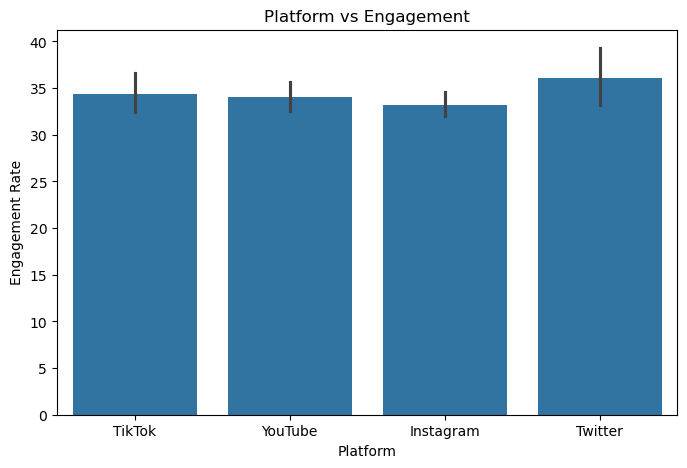

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="platform",
    y="Engagement_Rate"
)

plt.title("Platform vs Engagement")
plt.xlabel("Platform")
plt.ylabel("Engagement Rate")

plt.show()

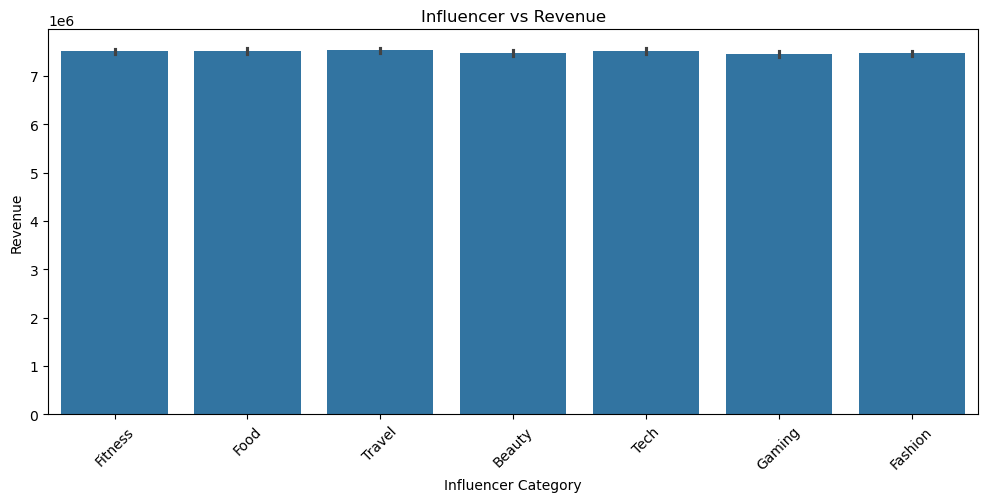

In [28]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="influencer_category",
    y="Revenue"
)

plt.xticks(rotation=45)

plt.title("Influencer vs Revenue")
plt.xlabel("Influencer Category")
plt.ylabel("Revenue")

plt.show()

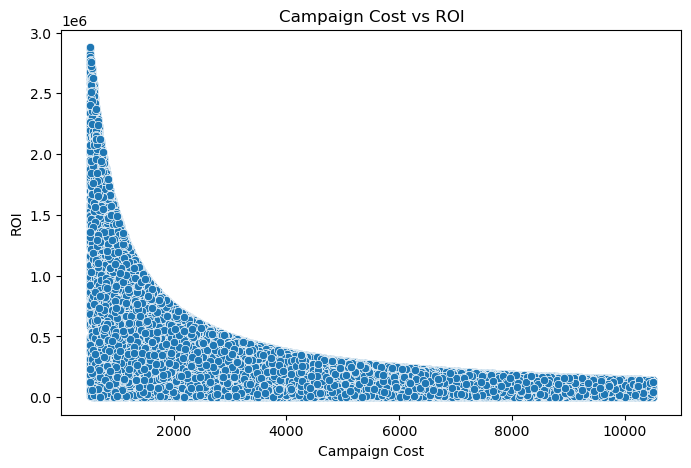

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Campaign_Cost",
    y="ROI"
)

plt.title("Campaign Cost vs ROI")
plt.xlabel("Campaign Cost")
plt.ylabel("ROI")

plt.show()

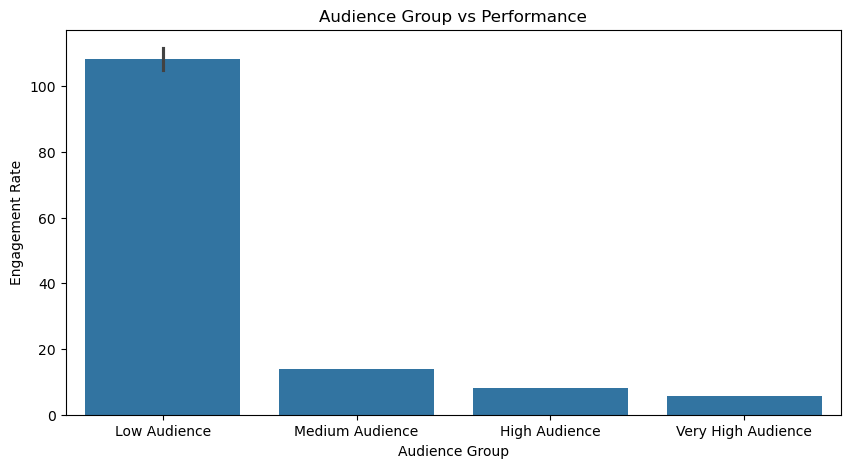

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df["Audience_Group"] = pd.qcut(
    df["estimated_reach"],
    q=4,
    labels=["Low Audience", "Medium Audience", "High Audience", "Very High Audience"],
    duplicates="drop"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Audience_Group",
    y="Engagement_Rate"
)

plt.title("Audience Group vs Performance")
plt.xlabel("Audience Group")
plt.ylabel("Engagement Rate")

plt.show()

In [31]:
print("Total Campaigns :", df["campaign_id"].nunique())

print("Total Reach :", df["estimated_reach"].sum())

print("Total Revenue :", df["Revenue"].sum())

print("Total Spend :", df["Campaign_Cost"].sum())

print("Average Engagement Rate :", round(df["Engagement_Rate"].mean(),2))

print("Average ROI :", round(df["ROI"].mean(),2))

Total Campaigns : 150000
Total Reach : 75035945238
Total Revenue : 1123978695000
Total Spend : 825359452.3799999
Average Engagement Rate : 33.97
Average ROI : 225966.74


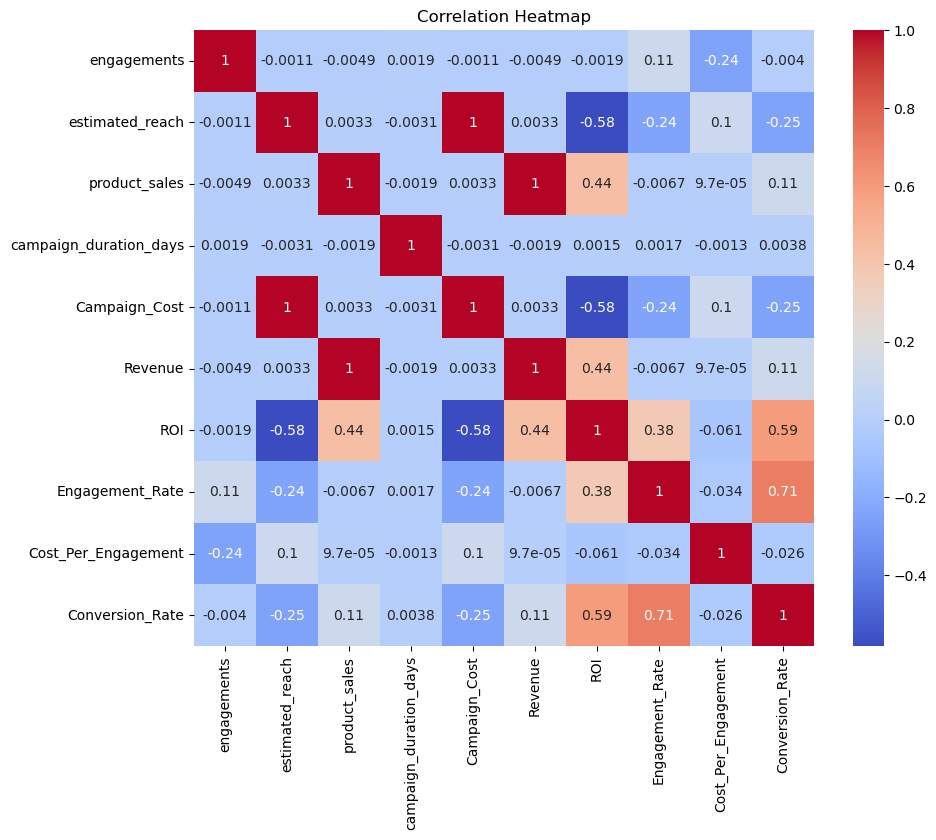

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

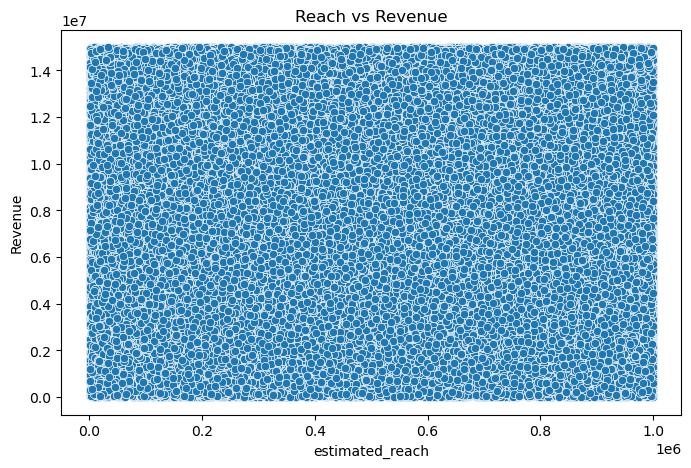

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="estimated_reach",
    y="Revenue"
)

plt.title("Reach vs Revenue")

plt.show()

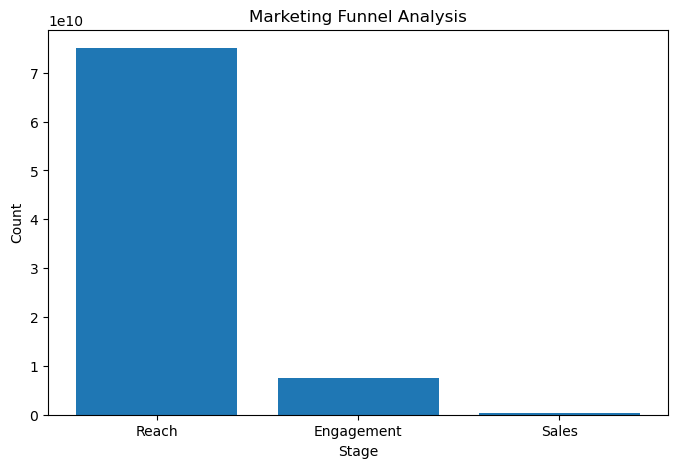

In [34]:
funnel = pd.DataFrame({
    "Stage":["Reach","Engagement","Sales"],
    "Count":[
        df["estimated_reach"].sum(),
        df["engagements"].sum(),
        df["product_sales"].sum()
    ]
})

plt.figure(figsize=(8,5))

plt.bar(
    funnel["Stage"],
    funnel["Count"]
)

plt.title("Marketing Funnel Analysis")

plt.xlabel("Stage")
plt.ylabel("Count")

plt.show()

In [35]:
df["ROI_Group"] = np.where(
    df["ROI"] >= df["ROI"].mean(),
    "High ROI Influencer",
    "Low ROI Influencer"
)

print(df["ROI_Group"].value_counts())

ROI_Group
Low ROI Influencer     107786
High ROI Influencer     42214
Name: count, dtype: int64


In [36]:
df["Influencer_Type"] = np.where(
    df["estimated_reach"] < df["estimated_reach"].median(),
    "Micro Influencer",
    "Mega Influencer"
)

print(df["Influencer_Type"].value_counts())

Influencer_Type
Micro Influencer    75000
Mega Influencer     75000
Name: count, dtype: int64


In [37]:
df["Engagement_Group"] = np.where(
    df["Engagement_Rate"] >= df["Engagement_Rate"].mean(),
    "High Engagement Creator",
    "Low Engagement Creator"
)

print(df["Engagement_Group"].value_counts())

Engagement_Group
Low Engagement Creator     128088
High Engagement Creator     21912
Name: count, dtype: int64


In [38]:
df["Cost_Efficient"] = np.where(
    df["Cost_Per_Engagement"] <= df["Cost_Per_Engagement"].mean(),
    "Cost Efficient",
    "High Cost"
)

print(df["Cost_Efficient"].value_counts())

Cost_Efficient
Cost Efficient    128470
High Cost          21530
Name: count, dtype: int64


In [39]:
print(pd.crosstab(df["ROI_Group"], df["platform"]))

platform             Instagram  TikTok  Twitter  YouTube
ROI_Group                                               
High ROI Influencer      16742    8436     4267    12769
Low ROI Influencer       43077   21548    10791    32370


In [40]:
print(pd.crosstab(df["Influencer_Type"], df["platform"]))

platform          Instagram  TikTok  Twitter  YouTube
Influencer_Type                                      
Mega Influencer       29950   15084     7486    22480
Micro Influencer      29869   14900     7572    22659


In [41]:
print(pd.crosstab(df["Engagement_Group"], df["platform"]))

platform                 Instagram  TikTok  Twitter  YouTube
Engagement_Group                                            
High Engagement Creator       8765    4316     2224     6607
Low Engagement Creator       51054   25668    12834    38532


In [42]:
print(pd.crosstab(df["Cost_Efficient"], df["platform"]))

platform        Instagram  TikTok  Twitter  YouTube
Cost_Efficient                                     
Cost Efficient      51234   25658    12920    38658
High Cost            8585    4326     2138     6481


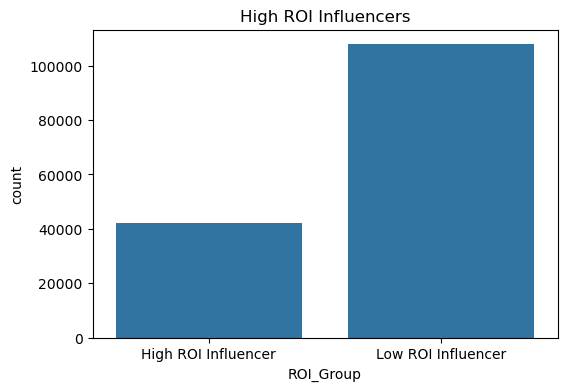

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="ROI_Group")

plt.title("High ROI Influencers")

plt.show()

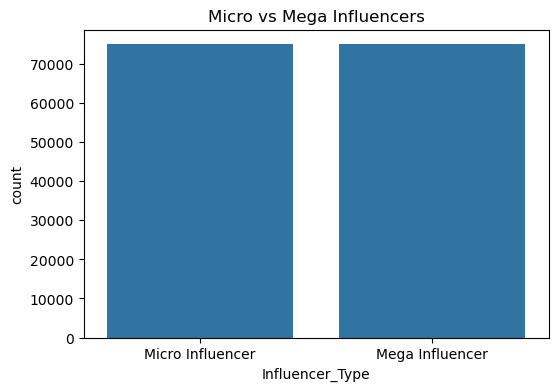

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Influencer_Type")

plt.title("Micro vs Mega Influencers")

plt.show()

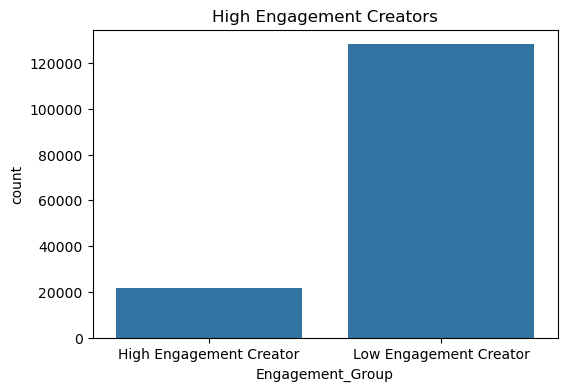

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Engagement_Group")

plt.title("High Engagement Creators")

plt.show()

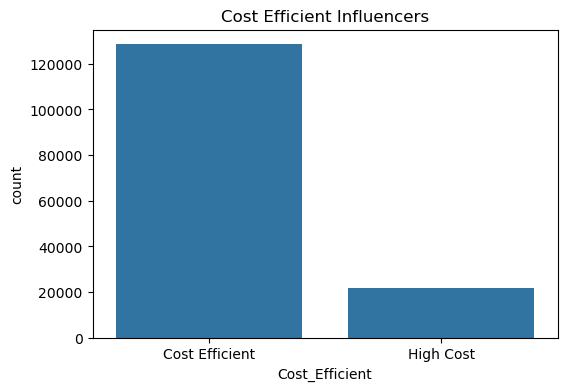

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Cost_Efficient")

plt.title("Cost Efficient Influencers")

plt.show()

In [47]:
print(df.columns.tolist())

['campaign_id', 'platform', 'influencer_category', 'campaign_type', 'start_date', 'engagements', 'estimated_reach', 'product_sales', 'campaign_duration_days', 'end_date', 'Campaign_Cost', 'Revenue', 'ROI', 'Engagement_Rate', 'Cost_Per_Engagement', 'Conversion_Rate', 'Audience_Group', 'ROI_Group', 'Influencer_Type', 'Engagement_Group', 'Cost_Efficient']


In [48]:
df.to_csv("Influencer_Campaign_Final.csv", index=False)

In [49]:
import os
os.getcwd()

'C:\\Users\\venka\\anaconda_projects\\51948ab8-c1ef-4727-915e-d98b4964face'

In [50]:
df.to_csv(
    r"C:\Users\venka\OneDrive\Desktop\Influencer_Campaign_Final.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
